# Figure 7.8-1 &mdash; why subcooling and superheating occur

Section 7.8 is the one place in this chapter where **size** enters thermodynamics. Every
other section treats a phase as a bulk object with no boundary worth accounting for. Here
the boundary is the whole story: a small drop has a large surface-to-volume ratio, the
surface costs energy, and the consequence is that a drop is *thermodynamically different
from the same liquid in bulk* at the same temperature and pressure.

That single fact explains a set of everyday observations that otherwise look like
violations of what the chapter has just established &mdash; water that stays liquid below
its freezing point, a liquid that will not boil until well past its boiling temperature,
and the way small ice crystals in an ice cream vanish while large ones grow.

**Figure 7.8-1** is the quantitative statement. It plots the molar Gibbs energy penalty a
drop pays for being small, for water at $20\,^\circ$C, over ten decades of radius. This
notebook generates it, and then does what a single curve cannot: it puts numbers on how
large the effect is, where it starts to matter, and where the macroscopic description this
book is built on stops being valid.

There is no numbered illustration in Section 7.8 &mdash; the section is a discussion, with
one figure and two data tables. So the calculation below is the section's argument, worked.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# This notebook labels its axes with the book's molar underbar, $\underline{V}$.
# With no LaTeX installed, matplotlib renders math with its own "mathtext"
# engine, which only learned \underline in version 3.11 -- and Colab still
# ships 3.10. Upgrade there; with a current matplotlib this does nothing.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("matplotlib upgraded - Runtime > Restart session, then Run all.")
# ---------------------------------------------------------------------------

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

## Surface tension and the pressure inside a drop

Adding a surface to the energy balance costs $\sigma\,dA$, where $\sigma$ is the surface
tension &mdash; the two-dimensional analog of the $P\,dV$ work a bulk fluid does against
its surroundings (Eq. 7.8-1). For a sphere, $V = \tfrac{4}{3}\pi r^{3}$ and
$A = 4\pi r^{2}$, so $dA/dV = 2/r$, and the surface term folds into the energy balance as
an **elevated internal pressure** (Eq. 7.8-2):

$$ P_{\mathrm{int}} = P + \frac{2\sigma}{r} $$

The liquid inside a drop is squeezed by its own surface. For a large drop
($r \to \infty$) this vanishes and the internal and external pressures agree; for a small
one it is enormous, as the numbers below will show.

$\sigma$ comes from **Table 7.8-1**, and the liquid molar volumes from the book's property
database, `code/data/pure_property.csv` (the digitized Appendix A), which happens to
tabulate liquid densities at 293 K &mdash; exactly the temperature of Table 7.8-1.

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants

# Typography, matching the other recomputed figures: use a real LaTeX installation when
# there is one, so the figure is set in Computer Modern like the book, and fall back to
# matplotlib's own mathtext otherwise — the notebook still runs in Colab, which has no
# TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

import sys
sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/
from thermo.data import get_compound

R = constants.R                     # J/(mol K)
TO_KELVIN = 273.15
DYNE_PER_CM = 1e-3                  # J/m^2 per dyne/cm  ("divide by 1000", Table 7.8-1)

T = 20.0 + TO_KELVIN                # the temperature of Figure 7.8-1
SIGMA_WATER = 72.9 * DYNE_PER_CM    # Table 7.8-1, water at 20 C


def molar_volume(name):
    """Liquid molar volume (m^3/mol) from pure_property.csv (Molwt in g/mol, Lden in
    g/cm^3 at Tden). Returns (V, Tden)."""
    row = get_compound(name)
    return row["Molwt"] * 1e-3 / (row["Lden"] * 1e3), row["Tden"]


V_WATER, Tden = molar_volume("water")

print(f"water at {T - TO_KELVIN:.0f} C")
print(f"  sigma  = {SIGMA_WATER:.4f} J/m^2  ({SIGMA_WATER / DYNE_PER_CM:.1f} dyne/cm)")
print(f"  V_L    = {V_WATER * 1e6:.3f} cm^3/mol   (density from the database at "
      f"{Tden:.0f} K)")
print(f"  RT     = {R * T:.1f} J/mol\n")

print("the Laplace pressure, P_int - P = 2 sigma / r:")
print(f"{'r':>12}{'P_int - P (bar)':>18}")
for r in (1e-9, 1e-8, 1e-7, 1e-6, 1e-3):
    print(f"{r:12.0e}{2 * SIGMA_WATER / r / 1e5:18.4g}")

water at 20 C
  sigma  = 0.0729 J/m^2  (72.9 dyne/cm)
  V_L    = 18.051 cm^3/mol   (density from the database at 293 K)
  RT     = 2437.4 J/mol

the Laplace pressure, P_int - P = 2 sigma / r:
           r   P_int - P (bar)
       1e-09              1458
       1e-08             145.8
       1e-07             14.58
       1e-06             1.458
       1e-03          0.001458


## The fugacity of a drop

The bulk liquid at $(T,P)$ has a fugacity $f^{L}(T,P)$ computable by any method in this
chapter. A *drop* of the same liquid at the same temperature and the same **external**
pressure is at the higher internal pressure $P_{\mathrm{int}}$, and applying the Poynting
correction (Eq. 7.4-18) across that pressure difference gives Eq. 7.8-3:

$$ f^{L}_{\mathrm{drop}}(T,P) = f^{L}(T, P_{\mathrm{int}})
   = f^{L}\!\left(T, P + \frac{2\sigma}{r}\right)
   = f^{L}(T,P)\,\exp\!\left(\frac{2\sigma}{rRT}\underline{V}^{L}\right) $$

The exponential is always greater than one, so **a drop always has a higher fugacity than
the bulk liquid**, and the smaller the drop the larger the excess.

Fugacity and molar Gibbs energy are related by Eq. 7.4-6, so the same statement in energy
terms is

$$ \underline{G}_{\mathrm{drop}} - \underline{G}
   = RT \ln\frac{f_{\mathrm{drop}}(T,P)}{f(T,P)}
   = \frac{2\sigma \underline{V}^{L}}{r} $$

which is what Figure 7.8-1 plots. Note what survived: $R$, $T$, and the fugacity of the
bulk liquid all canceled. The penalty depends only on the product $\sigma\underline{V}^{L}$
and on $1/r$ &mdash; so on log&ndash;log axes it is a straight line of slope $-1$, and its
height is set by a single number per liquid.

In [3]:
def delta_G(r, sigma=SIGMA_WATER, V=V_WATER):
    """Molar Gibbs energy of a drop of radius r (m) above the bulk liquid, J/mol."""
    return 2 * sigma * V / np.asarray(r, dtype=float)


print(f"2 sigma V_L = {2 * SIGMA_WATER * V_WATER:.4e} J m / mol   "
      f"(the whole liquid dependence)\n")
print(f"{'r':>12}{'dG (J/mol)':>14}")
for r in (1e-9, 1e-8, 1e-7, 1e-6, 1e-3, 1e0, 1e1):
    print(f"{r:12.0e}{delta_G(r):14.4g}")

2 sigma V_L = 2.6319e-06 J m / mol   (the whole liquid dependence)

           r    dG (J/mol)
       1e-09          2632
       1e-08         263.2
       1e-07         26.32
       1e-06         2.632
       1e-03      0.002632
       1e+00     2.632e-06
       1e+01     2.632e-07


## Figure 7.8-1

Both axes are logarithmic and both span an enormous range, because that is what the
physics demands: the radius runs from 1 nm &mdash; near the smallest drop the macroscopic
description can pretend to describe &mdash; out to 10 m, and the Gibbs energy penalty
across that range covers eleven decades. On these axes the relation
$\Delta\underline{G} = 2\sigma\underline{V}^{L}/r$ is a straight line of slope $-1$, and
the point of the figure is how far it runs: the penalty is utterly negligible for anything
you can see, and thousands of joules per mole for a drop a few molecules across.

The tick labels switch between decimal and power-of-ten notation where each is easier to
read, which is why 0.01 through 100 appear as plain numbers.

A high-resolution PDF is written to `pdf/Fig_7.8-1.pdf`.

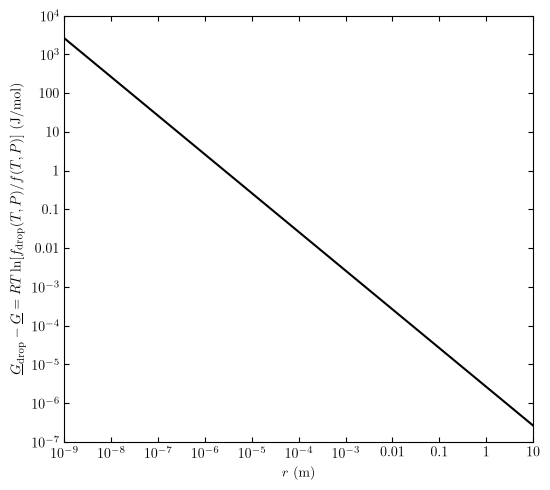

In [4]:
import os
from matplotlib.ticker import FuncFormatter, FixedLocator

R_LO, R_HI = 1e-9, 1e1              # drop radius, m
G_LO, G_HI = 1e-7, 1e4              # Gibbs energy penalty, J/mol
BLACK = "black"


def decade_label(v, _pos=None):
    """Plain decimals over 0.01-100, powers of ten outside — easiest to read either way."""
    if 1e-2 <= v <= 1e2:
        return f"{v:g}"
    e = int(round(np.log10(v)))
    return rf"$10^{{{e}}}$"


r = np.logspace(np.log10(R_LO), np.log10(R_HI), 400)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.plot(r, delta_G(r), "-", color=BLACK, lw=1.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(R_LO, R_HI)
ax.set_ylim(G_LO, G_HI)

# Label EVERY decade on both axes. LogLocator's default numticks would thin them out to
# every other decade over a range this wide, so the decades are placed explicitly.
for axis, lo, hi in ((ax.xaxis, R_LO, R_HI), (ax.yaxis, G_LO, G_HI)):
    decades = 10.0**np.arange(round(np.log10(lo)), round(np.log10(hi)) + 1)
    axis.set_major_locator(FixedLocator(decades))
    axis.set_major_formatter(FuncFormatter(decade_label))
    axis.set_minor_locator(FixedLocator([]))

ax.tick_params(which="both", top=True, right=True, direction="in")

ax.set_xlabel(r"$r$  (m)")
ax.set_ylabel(r"$\underline{G}_{\mathrm{drop}} - \underline{G} = "
              r"RT\ln[f_{\mathrm{drop}}(T,P)/f(T,P)]$  (J/mol)")

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Fig_7.8-1.pdf", dpi=300, bbox_inches="tight")
plt.show()

## How large is "large"?

A straight line over eleven decades is hard to read a magnitude off, so put the curve next
to something. The natural yardstick is $RT$ itself: it is the scale on which Gibbs energy
differences move equilibria, and $\Delta\underline{G}/RT$ is exactly the exponent in
Eq. 7.8-3, so it is also the factor by which the drop's fugacity is raised.

Define $r^{*}$ as the radius where the penalty equals $RT$:

$$ \frac{2\sigma\underline{V}^{L}}{r^{*}} = RT
   \qquad\Longrightarrow\qquad
   r^{*} = \frac{2\sigma\underline{V}^{L}}{RT} $$

In [5]:
r_star = 2 * SIGMA_WATER * V_WATER / (R * T)
print(f"r* = {r_star:.3e} m = {r_star * 1e9:.2f} nm   for water at {T - TO_KELVIN:.0f} C\n")

rows = []
for r_ in (1e-9, 3e-9, 1e-8, 3e-8, 1e-7, 1e-6, 1e-5, 1e-3, 1e-1):
    dG = delta_G(r_)
    rows.append({"r (m)": r_, "dG (J/mol)": dG, "dG / RT": dG / (R * T),
                 "P_int - P (bar)": 2 * SIGMA_WATER / r_ / 1e5,
                 "f_drop / f": np.exp(dG / (R * T))})

print(pd.DataFrame(rows).to_string(index=False, formatters={
    "r (m)": "{:.0e}".format, "dG (J/mol)": "{:.4g}".format,
    "dG / RT": "{:.4g}".format, "P_int - P (bar)": "{:.4g}".format,
    "f_drop / f": "{:.4f}".format}))

print(f"""
Reading this: at a micron the drop's fugacity is raised by about one part in a thousand —
thermodynamically invisible, and this is already a drop far smaller than a fog droplet.
At 10 nm it is {100*(np.exp(delta_G(1e-8)/(R*T))-1):.0f}% and starting to matter. At 1 nm it is a factor of
{np.exp(delta_G(1e-9)/(R*T)):.2f}, and the internal pressure is {2*SIGMA_WATER/1e-9/1e5:.0f} bar.

So the entire interesting range of Figure 7.8-1 — everything that could shift a phase
equilibrium — is the last decade and a half on the left.""")

r* = 1.080e-09 m = 1.08 nm   for water at 20 C

r (m) dG (J/mol)  dG / RT P_int - P (bar) f_drop / f
1e-09       2632     1.08            1458     2.9440
3e-09      877.3   0.3599             486     1.4332
1e-08      263.2    0.108           145.8     1.1140
3e-08      87.73  0.03599            48.6     1.0366
1e-07      26.32   0.0108           14.58     1.0109
1e-06      2.632  0.00108           1.458     1.0011
1e-05     0.2632 0.000108          0.1458     1.0001
1e-03   0.002632 1.08e-06        0.001458     1.0000
1e-01  2.632e-05 1.08e-08       1.458e-05     1.0000

Reading this: at a micron the drop's fugacity is raised by about one part in a thousand —
thermodynamically invisible, and this is already a drop far smaller than a fog droplet.
At 10 nm it is 11% and starting to matter. At 1 nm it is a factor of
2.94, and the internal pressure is 1458 bar.

So the entire interesting range of Figure 7.8-1 — everything that could shift a phase
equilibrium — is the last decade and a hal

### Where the macroscopic description gives out

That last decade and a half is also where this book's whole framework runs out, and
Section 7.8 says so explicitly:

> The expression for the internal pressure indicates that it becomes infinite in the limit
> of a drop of the size of a single molecule. However, when only one or a few molecules are
> involved, one must use a statistical mechanical description, not the macroscopic
> thermodynamic description in this book.

It is worth making that concrete rather than leaving it as a caution, because the two
scales &mdash; where the effect becomes thermodynamically significant, and where the theory
fails &mdash; turn out to be *the same scale*. There is no comfortable window in between.

In [6]:
v_molecule = V_WATER / constants.N_A                       # m^3 per molecule
r_molecule = (3 * v_molecule / (4 * np.pi))**(1 / 3)       # effective molecular radius
d_molecule = 2 * r_molecule                                # effective molecular diameter

print(f"volume per water molecule      {v_molecule:.3e} m^3")
print(f"effective molecular diameter   {d_molecule * 1e9:.3f} nm")
print(f"r* (penalty = RT)              {r_star * 1e9:.3f} nm\n")

print(f"{'r':>10}{'molecules in the drop':>24}{'drop diameters':>17}{'dG / RT':>10}")
print(f"{'':>10}{'':>24}{'(molecular)':>17}")
for r_ in (r_star, 1e-9, 2e-9, 5e-9, 1e-8, 1e-7):
    n = (4 / 3) * np.pi * r_**3 / v_molecule
    tag = " <- r*" if r_ == r_star else ""
    print(f"{r_:10.2e}{n:24.0f}{2 * r_ / d_molecule:17.1f}{delta_G(r_) / (R * T):10.3f}{tag}")

n_star = (4 / 3) * np.pi * r_star**3 / v_molecule
print(f"""
A drop at r* holds about {n_star:.0f} water molecules and is {2*r_star/d_molecule:.1f} molecular diameters
across — so a large fraction of them are IN the surface, and "surface tension" as a bulk
material property is already a fiction there.

This is the honest reading of Figure 7.8-1: the left edge of the plot is not a limit of
the graph, it is the limit of the theory. The curve is quantitatively trustworthy where
the effect is small, and where the effect is large it is telling you the right story
qualitatively while the numbers should be taken as an estimate.""")

volume per water molecule      2.997e-29 m^3
effective molecular diameter   0.385 nm
r* (penalty = RT)              1.080 nm

         r   molecules in the drop   drop diameters   dG / RT
                                        (molecular)
  1.08e-09                     176              5.6     1.000 <- r*
  1.00e-09                     140              5.2     1.080
  2.00e-09                    1118             10.4     0.540
  5.00e-09                   17468             25.9     0.216
  1.00e-08                  139745             51.9     0.108
  1.00e-07               139744842            518.9     0.011

A drop at r* holds about 176 water molecules and is 5.6 molecular diameters
across — so a large fraction of them are IN the surface, and "surface tension" as a bulk
material property is already a fiction there.

This is the honest reading of Figure 7.8-1: the left edge of the plot is not a limit of
the graph, it is the limit of the theory. The curve is quantitatively trustworthy

## Why this explains subcooling, superheating, and Ostwald ripening

Everything Section 7.8 concludes follows from the sign and the shape of that curve.

**A drop boils more easily than the bulk.** Its fugacity is higher, so it reaches
1.013 bar at a lower temperature &mdash; small drops vaporize below the bulk boiling
point. And as a drop evaporates it gets *smaller*, which raises its fugacity further and
raises its surface-to-volume ratio: the process accelerates as it goes. That is why an air
freshener atomizes.

**Condensation has to pay upfront.** A vapor can only condense by first making a drop, and
the first drop is infinitesimal, so it sits at the far top-left of Figure 7.8-1 where the
Gibbs energy is enormous. Cooling a clean vapor past its condensation temperature does not
condense it, because although bulk liquid would be favorable, the *first small drop* is
not. That is **subcooling**. The same argument with a vapor bubble inside a liquid gives
**superheating**, and with a crystal gives the subcooling of a freezing liquid.

**Big crystals eat small ones.** Figure 7.8-1 says large radius means low Gibbs energy. A
population of crystals of mixed size therefore lowers its total Gibbs energy by dissolving
the small ones and growing the large ones. That is **Ostwald ripening** &mdash; and it is
why ice cream goes gritty in a freezer that cycles.

The quantitative version of the first statement is worth writing down, because it is a
named result. At low pressure $f \approx P$, so Eq. 7.8-3 becomes the **Kelvin equation**:

$$ \frac{P^{\mathrm{vap}}(r)}{P^{\mathrm{vap}}(\infty)}
   = \exp\!\left(\frac{2\sigma\underline{V}^{L}}{rRT}\right) $$

*The plot below is not a book figure* &mdash; Section 7.8 carries only Figure 7.8-1. It is
a diagnostic, so it gets no QR key and no PDF is written.

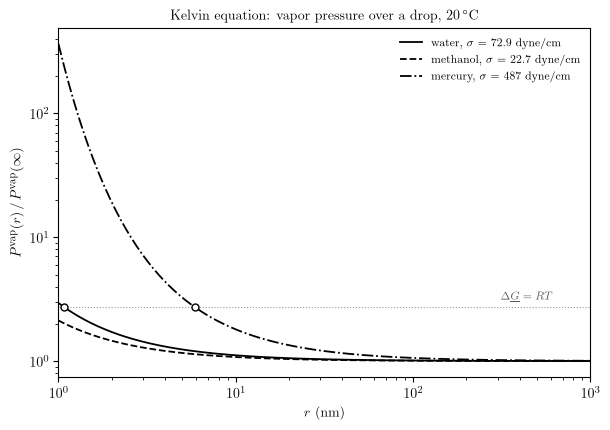

open circles mark r*, where the penalty equals RT and the ratio is e = 2.718


In [7]:
LIQUIDS = [("water", 72.9), ("methanol", 22.7), ("mercury", 487.0)]

fig, ax = plt.subplots(figsize=(6.2, 4.4))
r = np.logspace(-9, -6, 300)

for (name, sig_dyne), style in zip(LIQUIDS, ("-", "--", "-.")):
    V, _ = molar_volume(name)
    sigma = sig_dyne * DYNE_PER_CM
    ratio = np.exp(delta_G(r, sigma, V) / (R * T))
    ax.plot(r * 1e9, ratio, style, color="black", lw=1.3,
            label=rf"{name}, $\sigma$ = {sig_dyne:g} dyne/cm")
    rs = 2 * sigma * V / (R * T)
    ax.plot([rs * 1e9], [np.e], "o", mfc="white", mec="black", ms=5, mew=1.0, zorder=3)

ax.axhline(np.e, color="0.6", lw=0.8, ls=":")
ax.annotate(r"$\Delta\underline{G} = RT$", xy=(600, np.e), xytext=(0, 4),
            textcoords="offset points", ha="right", va="bottom", fontsize=8, color="0.35")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 1000)
ax.set_xlabel(r"$r$  (nm)")
ax.set_ylabel(r"$P^{\mathrm{vap}}(r) \,/\, P^{\mathrm{vap}}(\infty)$")
ax.set_title(r"Kelvin equation: vapor pressure over a drop, $20\,^\circ$C", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

print("open circles mark r*, where the penalty equals RT and the ratio is e = 2.718")

### Which liquids pay the most?

The penalty is set by $\sigma\underline{V}^{L}$, not by $\sigma$ alone &mdash; a point
easy to miss, since Table 7.8-1 tabulates only the surface tension. Water has the highest
surface tension of any ordinary liquid in that table, but also much the smallest molar
volume, and the two largely cancel.

Below, every Table 7.8-1 liquid at $20\,^\circ$C whose density the property database
carries, ranked by $r^{*}$.

In [8]:
TABLE_7_8_1 = [                       # (name, sigma in dyne/cm), all at 20 C
    ("water", 72.9), ("methanol", 22.7), ("ethanol", 22.1), ("1-octanol", 27.6),
    ("benzene", 28.9), ("aniline", 43.4), ("glycerol", 64.0), ("perfluorohexane", 11.9),
    ("n-heptane", 20.4), ("n-octane", 21.6), ("propionic acid", 26.7), ("mercury", 487.0),
]

rows, missing = [], []
for name, sig_dyne in TABLE_7_8_1:
    try:
        V, Td = molar_volume(name)
    except KeyError:
        missing.append(name)
        continue
    sigma = sig_dyne * DYNE_PER_CM
    rows.append({"liquid": name, "sigma (dyne/cm)": sig_dyne, "V_L (cm3/mol)": V * 1e6,
                 "2 sigma V_L": 2 * sigma * V, "r* (nm)": 2 * sigma * V / (R * T) * 1e9,
                 "Tden (K)": Td})

out = pd.DataFrame(rows).sort_values("r* (nm)")
print(out.to_string(index=False, formatters={
    "sigma (dyne/cm)": "{:.1f}".format, "V_L (cm3/mol)": "{:.2f}".format,
    "2 sigma V_L": "{:.3e}".format, "r* (nm)": "{:.2f}".format,
    "Tden (K)": "{:.0f}".format}))

if missing:
    print(f"\nomitted, no liquid density in pure_property.csv: {', '.join(missing)}")
print(f"""
Table 7.8-1's other two entries, sodium (139 C) and sodium chloride (1073 C), are left out
because the database liquid densities are near 293 K and would not apply at those
temperatures.

Note benzene's density is tabulated at 289 K rather than 293 K — a ~0.5% effect on V_L,
well below the precision of anything here.

The ranking is not the surface-tension ranking. Water has by far the highest surface
tension of the ordinary liquids listed, and lands third from the bottom, because its molar
volume is the smallest of the set — methanol has less than a third of water's surface
tension but more than twice its molar volume, and the two end up within 40% of each other.
Mercury tops the list on surface tension alone: at 487 dyne/cm it overwhelms the fact that
its molar volume is smaller than water's.

And the whole spread, from methanol to molten mercury, is a factor of {out['r* (nm)'].max()/out['r* (nm)'].min():.0f} in r* — which
is the real message. Whatever the liquid, this is a nanometre-scale effect.""")

        liquid sigma (dyne/cm) V_L (cm3/mol) 2 sigma V_L r* (nm) Tden (K)
      methanol            22.7         40.51   1.839e-06    0.75      293
       ethanol            22.1         58.39   2.581e-06    1.06      293
         water            72.9         18.05   2.632e-06    1.08      293
propionic acid            26.7         74.60   3.984e-06    1.63      293
       benzene            28.9         88.26   5.102e-06    2.09      289
     n-heptane            20.4        146.50   5.977e-06    2.45      293
      n-octane            21.6        162.49   7.020e-06    2.88      293
       aniline            43.4         91.12   7.910e-06    3.25      293
     1-octanol            27.6        157.66   8.703e-06    3.57      293
      glycerol            64.0         73.03   9.348e-06    3.84      293
       mercury           487.0         14.76   1.437e-05    5.90      293

omitted, no liquid density in pure_property.csv: perfluorohexane

Table 7.8-1's other two entries, sodium (139 

## What this section shows

**Thermodynamics acquires a length scale.** Everywhere else in this book a phase is
specified by two intensive variables and nothing else &mdash; two samples of liquid water
at the same $T$ and $P$ are the same substance. Section 7.8 breaks that: a drop and a
bucket differ, and the parameter that separates them is $r$. It is the one place in the
chapter where the *size* of your system is a state variable.

**But only barely, and only at the nanometre scale.** For water at $20\,^\circ$C the
penalty reaches $RT$ at $r^{*} = 1.08$ nm. At 1 µm &mdash; still far smaller than any
droplet you will ever see &mdash; the fugacity is raised by one part in a thousand. This
is why the effect can be ignored in every other chapter, and it is worth being clear that
Figure 7.8-1's ten decades of radius exist to show how *fast* the effect dies, not how far
it reaches.

**The interesting regime and the invalid regime are the same regime.** A drop of radius
$r^{*}$ is about 5.6 molecular diameters across and holds around 180 molecules, a large
fraction of them in its own surface. So the curve is quantitatively reliable exactly where
it is uninteresting, and where it predicts something dramatic it is being pushed past the
assumptions behind it. The right conclusion is the one the section draws &mdash; a
qualitative barrier to nucleation exists and is large &mdash; not a number for the height
of that barrier.

**And a barrier explains what equilibrium alone cannot.** Chapter 7 is about equilibrium
states: which phase has the lower Gibbs energy. Subcooling and superheating are cases
where the system knows perfectly well which state is favorable and *cannot get there*,
because the path runs through small drops or small bubbles that are not favorable. That
distinction &mdash; between the destination and the route &mdash; is the seed of kinetics,
and it is the reason a bumping flask and a boiling chip both belong in a thermodynamics
course.

### Things to try

1. **Find the boiling point of a small drop** (Problem 7.72). A drop boils when
   $f_{\mathrm{drop}} = 1.013$ bar. Using the Antoine constants fitted in
   [`clausius_clapeyron_isooctane.ipynb`](clausius_clapeyron_isooctane.ipynb), or steam
   data for water, find the temperature at which a 10 nm drop boils. How far below the
   bulk boiling point is it?
2. **Bubbles, not drops.** Redo the argument for a vapor bubble inside a liquid, which is
   the superheating case. The Laplace pressure is the same, but which phase's molar volume
   enters, and how much larger is the result? (This is the difference between a curve that
   matters at nanometres and one that matters at microns.)
3. **Temperature dependence.** $\sigma$ falls with temperature and vanishes at the critical
   point. Look up $\sigma(T)$ for water, or use the empirical
   $\sigma \propto (1 - T/T_c)^{11/9}$, and plot $r^{*}(T)$. Does nucleation get easier or
   harder near the critical point, and does that match your intuition about how a
   near-critical fluid looks?
4. **Ostwald ripening, quantitatively.** Two crystals of radii 10 nm and 100 nm sit in the
   same solution. Compute the Gibbs energy difference per mole between them. Then compute
   the difference in their solubilities, which follows the same exponential as the Kelvin
   equation. Which one is dissolving?
5. **The other table.** Table 7.8-2 gives liquid&ndash;liquid interfacial tensions. Repeat
   the $r^{*}$ calculation for an emulsion droplet of one liquid in another, and comment on
   why emulsions can be made stable at sizes where a drop in air would not be.